# Bachelorproef — POC: Automatische detectie van open/gesloten status van supermarkten

**Auteur:** Maxim Van Der Schueren  
**Academiejaar:** 2025–2026   

---

**Labelstrategie:**
- `is_active = 1` → open
- `is_active = 0` → gesloten (scraper was actief maar registreerde POI als inactief)
- `is_deleted = 1` → extra feature, **niet** als label

---
## 0. Configuratie & bibliotheken

Pas `DATA_PATH` aan om te wisselen tussen de Delhaize-testset en de volledige dataset.

In [ ]:
# ── Configuratie ──────────────────────────────────────────────────────────────
DATA_PATH   = "../../data accurat/data name like =delhaize.csv"   # Delhaize testset
# DATA_PATH = "../data accurat/volledige_dataset.csv"  # Volledige dataset

MODEL_DIR   = "./models"         
RANDOM_SEED = 42
TEST_SIZE   = 0.2

# ── Bibliotheken ──────────────────────────────────────────────────────────────
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import joblib

import xgboost as xgb
import holidays

---
## 1. Data inladen

De data is een CSV-export van drie samengevoegde tabellen:
- **status_history** — historische open/gesloten registraties (`is_active`, `start`, `end`)
- **POI basisinfo** — naam, adres, categorie, merk, …
- **openingsuren** — verwachte openingstijden per dag (`day_of_week`, `stop`, `pause_start`, `pause_stop`, …)

In [20]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Geladen: {df_raw.shape[0]:,} rijen × {df_raw.shape[1]} kolommen")
df_raw.head(3)

Geladen: 20,602 rijen × 51 kolommen


,id,poi_id,start,end,is_active,inserted_at,updated_at,id.1,name,street,...,pause_stop,stop,appointment,closed,ok,inserted_at.2,updated_at.2,date,start_valid,end_valid
0,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,19:00:00,NaN,0,1,2024-08-02 11:42:08,2024-08-02 11:42:08,NaN,NaN,NaN
1,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,18:00:00,NaN,0,1,2025-06-26 07:01:05,2025-06-26 07:01:05,NaN,2023-12-25,2023-12-25
2,946095,389058,NaN,2023-09-30,0,2024-08-02 13:46:25,2024-08-02 13:46:25,389058,Delhaize,Chaussée de Tournai,...,NaN,18:00:00,NaN,0,1,2025-06-26 07:09:17,2025-06-26 07:09:17,NaN,2024-01-01,2024-01-01


In [21]:
# Datatypes bekijken
df_raw.dtypes

id                    int64
poi_id                int64
start                object
end                  object
is_active             int64
inserted_at          object
updated_at           object
id.1                  int64
name                 object
street               object
nbr                  object
box                  object
zip                   int64
city                 object
country              object
priority            float64
source               object
source_id            object
point                object
polygon              object
is_active.1           int64
visit                 int64
work                  int64
main_category_id    float64
brand_id            float64
inserted_at.1        object
updated_at.1         object
district_id         float64
client_id           float64
description         float64
is_sensitive          int64
pass                  int64
poi_parent_id       float64
cluster               int64
is_deleted            int64
is_reserved_poi     

In [22]:
# Ontbrekende waarden per kolom
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "percentage": missing_pct})
missing_df[missing_df["missing"] > 0].sort_values("percentage", ascending=False)

,missing,percentage
description,20602,100.00
pause_start,20602,100.00
priority,20602,100.00
date,20602,100.00
main_category_id,20602,100.00
appointment,20602,100.00
district_id,20602,100.00
client_id,20602,100.00
pause_stop,20602,100.00
poi_parent_id,20602,100.00


In [23]:
df = df_raw.copy()

# Kolommen met 100% ontbrekende waarden verwijderen 
volledig_leeg = df.columns[df.isnull().mean() == 1.0].tolist()
if volledig_leeg:
    df.drop(columns=volledig_leeg, inplace=True)
    print(f"Verwijderde kolommen: {volledig_leeg}")

Verwijderde kolommen: ['priority', 'main_category_id', 'district_id', 'client_id', 'description', 'poi_parent_id', 'pause_start', 'pause_stop', 'appointment', 'date']


In [24]:
# Datumkolommen parsen
for col in ["start", "end", "start_valid", "end_valid"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
df.dtypes

id                          int64
poi_id                      int64
start              datetime64[ns]
end                datetime64[ns]
is_active                   int64
inserted_at                object
updated_at                 object
id.1                        int64
name                       object
street                     object
nbr                        object
box                        object
zip                         int64
city                       object
country                    object
source                     object
source_id                  object
point                      object
polygon                    object
is_active.1                 int64
visit                       int64
work                        int64
brand_id                  float64
inserted_at.1              object
updated_at.1               object
is_sensitive                int64
pass                        int64
cluster                     int64
is_deleted                  int64
is_reserved_po

# 2. Data analyse

### 2.1 Verdeling open / gesloten

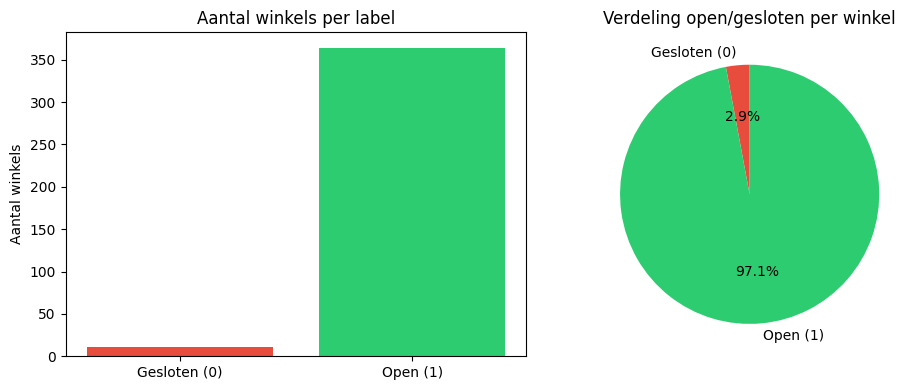

           aantal  percentage
is_active                    
0              11        2.93
1             364       97.07


In [31]:
df_basis = pd.read_csv("../../data accurat/basisinfo delhaize.csv", low_memory=False)

label_counts = df_basis["is_active"].value_counts().sort_index()
label_pct    = label_counts / len(df_basis) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Gesloten (0)", "Open (1)"], label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Aantal winkels per label")
axes[0].set_ylabel("Aantal winkels")

axes[1].pie(label_counts.values, labels=["Gesloten (0)", "Open (1)"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Verdeling open/gesloten per winkel")

plt.tight_layout()
plt.show()

print(label_counts.to_frame("aantal").assign(percentage=label_pct.round(2)))

### 2.2 Verdeling per merk 

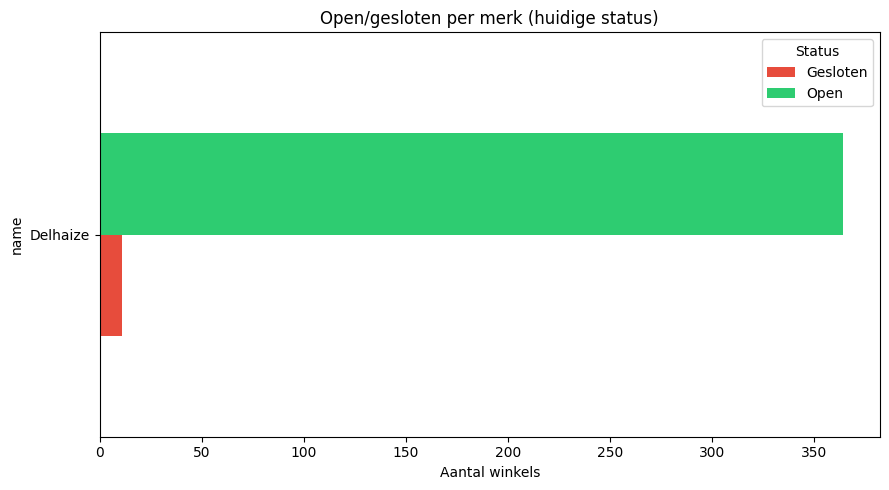

In [40]:
brand_status = (df_basis.groupby("name")["is_active"]
                        .value_counts()
                        .unstack(fill_value=0)
                        .rename(columns={0: "Gesloten", 1: "Open"}))

brand_status.plot(kind="barh", figsize=(9, 5), color=["#e74c3c", "#2ecc71"])
plt.xlabel("Aantal winkels")
plt.title("Open/gesloten per merk (huidige status)")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

---
## 3. Feature engineering

We leiden nieuwe features af uit de ruwe data om het model meer context te geven over wanneer een POI verwacht open of gesloten te zijn.

In [ ]:
# ── 3.1 Tijdsfeatures uit 'start' ────────────────────────────────────────────
if "start" in df.columns:
    df["uur_van_dag"]      = df["start"].dt.hour
    df["dag_van_week"]     = df["start"].dt.dayofweek          # 0=Ma … 6=Zo
    df["maand"]            = df["start"].dt.month
    df["is_weekend"]       = (df["dag_van_week"] >= 5).astype(int)
    print("Tijdsfeatures aangemaakt.")

In [ ]:
# ── 3.2 Verwachte openingsduur op basis van openingsuren ─────────────────────
# stop (sluitingstijd) en pause_start / pause_stop zijn datetime-kolommen
# We berekenen de netto openingsduur in minuten.

def bereken_openingsduur(row):
    """Bereken netto openingsduur in minuten op basis van openings-/sluitingstijd."""
    try:
        start_dt = row["start"]
        stop_dt  = row["stop"] if pd.notna(row.get("stop")) else None
        if pd.isna(start_dt) or stop_dt is None:
            return np.nan
        # Gebruik alleen het tijdgedeelte voor duurberekening
        duur = (stop_dt - start_dt).total_seconds() / 60
        # Trek pauze af indien aanwezig
        if pd.notna(row.get("pause_start")) and pd.notna(row.get("pause_stop")):
            pauze = (row["pause_stop"] - row["pause_start"]).total_seconds() / 60
            duur -= max(pauze, 0)
        return max(duur, 0)
    except Exception:
        return np.nan

if "stop" in df.columns:
    df["verwachte_openingsduur_min"] = df.apply(bereken_openingsduur, axis=1)
    print(f"Verwachte openingsduur — mediaan: {df['verwachte_openingsduur_min'].median():.0f} min")
else:
    df["verwachte_openingsduur_min"] = np.nan
    print("Kolom 'stop' niet gevonden — openingsduur ingesteld op NaN.")

In [ ]:
# ── 3.3 Afwijking: geplande duur vs. werkelijke duur ─────────────────────────
# Werkelijke duur = end - start (duur van de statusregistratie)
if "end" in df.columns and "start" in df.columns:
    df["werkelijke_duur_min"] = (
        (df["end"] - df["start"]).dt.total_seconds() / 60
    ).clip(lower=0)
    df["afwijking_duur_min"] = df["werkelijke_duur_min"] - df["verwachte_openingsduur_min"]
    print("Afwijkingsfeature aangemaakt.")
else:
    df["werkelijke_duur_min"] = np.nan
    df["afwijking_duur_min"]  = np.nan

In [ ]:
# ── 3.4 is_deleted als feature ────────────────────────────────────────────────
if "is_deleted" in df.columns:
    df["is_deleted"] = df["is_deleted"].fillna(0).astype(int)
    print("is_deleted als feature opgenomen.")

In [ ]:
# ── 3.5 Categorische features encoden ────────────────────────────────────────
le = LabelEncoder()

for col in ["brand_id", "main_category_id", "district_id"]:
    if col in df.columns:
        df[col] = df[col].fillna("onbekend").astype(str)
        df[col + "_enc"] = le.fit_transform(df[col])
        print(f"{col} geëncodeerd ({df[col].nunique()} unieke waarden).")

In [ ]:
# ── 3.6 Belgische feestdagen als feature ──────────────────────────────────────
be_holidays = holidays.Belgium(years=range(2018, 2027))

if "start" in df.columns:
    df["is_feestdag"] = df["start"].dt.date.map(
        lambda d: int(d in be_holidays) if pd.notna(d) else 0
    )
    print(f"Belgische feestdagen feature: {df['is_feestdag'].sum():,} feestdagrecords.")
else:
    df["is_feestdag"] = 0

In [ ]:
# ── 3.7 Overzicht van alle features ──────────────────────────────────────────
FEATURE_COLS = [
    col for col in [
        "uur_van_dag", "dag_van_week", "maand", "is_weekend", "is_feestdag",
        "verwachte_openingsduur_min", "werkelijke_duur_min", "afwijking_duur_min",
        "is_deleted",
        "brand_id_enc", "main_category_id_enc", "district_id_enc",
        "priority", "visit", "work",
        "closed", "ok", "appointment",
        "day_of_week",
    ]
    if col in df.columns
]

TARGET_COL = "is_active"

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

---
## 4. Train/test-splitsing

In [ ]:
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna(subset=[TARGET_COL])

# Numerieke kolommen: ontbrekende waarden opvullen met mediaan
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median(numeric_only=True))

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Label-verdeling train — open: {y_train.mean():.2%}")
print(f"Label-verdeling test  — open: {y_test.mean():.2%}")

---
## 5. Hulpfuncties

In [ ]:
def evalueer_model(naam, model, X_test, y_test):
    """Evalueer een getraind model en toon confusion matrix + rapport."""
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"Model: {naam}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Gesloten", "Open"]))

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=["Gesloten", "Open"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion matrix — {naam}")
    plt.tight_layout()
    plt.show()

    return {"model": naam, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def plot_feature_importance(naam, model, feature_names, top_n=15):
    """Toon een horizontale barplot met de top feature importances."""
    importances = model.feature_importances_
    idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    plt.barh(np.array(feature_names)[idx], importances[idx], color="#2980b9")
    plt.xlabel("Feature importance")
    plt.title(f"Top {top_n} features — {naam}")
    plt.tight_layout()
    plt.show()


resultaten = []   # Verzamelt metrics voor de vergelijkingstabel
print("Hulpfuncties gedefinieerd.")

---
## 6. Model 1 — Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest getraind.")

In [ ]:
rf_metrics = evalueer_model("Random Forest", rf, X_test, y_test)
resultaten.append(rf_metrics)

In [ ]:
plot_feature_importance("Random Forest", rf, FEATURE_COLS)

In [ ]:
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.joblib"))
print("Random Forest opgeslagen.")

---
## 7. Model 2 — XGBoost

In [ ]:
# Bereken class-gewicht voor onbalans
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos if pos > 0 else 1

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("XGBoost getraind.")

In [ ]:
xgb_metrics = evalueer_model("XGBoost", xgb_model, X_test, y_test)
resultaten.append(xgb_metrics)

In [ ]:
plot_feature_importance("XGBoost", xgb_model, FEATURE_COLS)

In [ ]:
joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgboost.joblib"))
print("XGBoost opgeslagen.")

---
## 8. Model 3 — Anomaliedetectie (Isolation Forest) *(optioneel)*

> **Let op:** Isolation Forest is een *unsupervised* methode die afwijkingen detecteert zonder gelabelde data.
> Dit model is alleen zinvol als er **tijdreeksdata** (bv. bezoekersaantallen, sensordata) of **voetgangersdata** beschikbaar is die een typisch patroon beschrijft.  
> Met de huidige features en labelstrategie (`is_active`) is dit een experimentele sectie — gebruik de resultaten ter aanvulling, niet als vervanging van de gesuperviseerde modellen.

In [ ]:
# ── Isolation Forest ─────────────────────────────────────────────────────────
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # Geschatte fractie anomalieën in de data
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_train)

# Isolation Forest geeft -1 (anomalie) of 1 (normaal) terug
# We mappen dit naar 0 (gesloten/afwijkend) en 1 (open/normaal)
y_pred_iso_raw = iso.predict(X_test)
y_pred_iso     = np.where(y_pred_iso_raw == 1, 1, 0)

iso_metrics = {
    "model"    : "Isolation Forest",
    "accuracy" : accuracy_score(y_test, y_pred_iso),
    "precision": precision_score(y_test, y_pred_iso, zero_division=0),
    "recall"   : recall_score(y_test, y_pred_iso, zero_division=0),
    "f1"       : f1_score(y_test, y_pred_iso, zero_division=0),
}
resultaten.append(iso_metrics)

print(classification_report(y_test, y_pred_iso, target_names=["Gesloten", "Open"]))

disp_iso = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_iso),
    display_labels=["Gesloten", "Open"]
)
fig, ax = plt.subplots(figsize=(5, 4))
disp_iso.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion matrix — Isolation Forest")
plt.tight_layout()
plt.show()

joblib.dump(iso, os.path.join(MODEL_DIR, "isolation_forest.joblib"))
print("Isolation Forest opgeslagen.")

---
## 9. Modelvergelijking

In [ ]:
# ── Overzichtstabel ───────────────────────────────────────────────────────────
df_resultaten = pd.DataFrame(resultaten).set_index("model")
df_resultaten = df_resultaten.rename(columns={
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-score"
})

display(df_resultaten.style
        .format("{:.4f}")
        .highlight_max(color="#a8d5a2", axis=0)
        .highlight_min(color="#f5a9a9", axis=0)
        .set_caption("Modelvergelijking — hogere waarden zijn beter"))

In [ ]:
# ── Barplot per metric ────────────────────────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x       = np.arange(len(metrics))
width   = 0.25
kleuren = ["#2980b9", "#27ae60", "#e67e22"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (naam, rij) in enumerate(df_resultaten.iterrows()):
    ax.bar(x + i * width, rij[metrics].values, width, label=naam, color=kleuren[i % len(kleuren)])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Modelvergelijking per metric")
ax.legend(loc="lower right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Waarde-labels boven de balken
for patch in ax.patches:
    h = patch.get_height()
    ax.annotate(f"{h:.3f}",
                xy=(patch.get_x() + patch.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

---
## 10. Conclusie

*(Vul in na het uitvoeren van het notebook.)*

| Aspect | Bevinding |
|--------|-----------|
| Beste model (F1) | *(in te vullen)* |
| Meest informatieve features | *(in te vullen)* |
| Klasse-onbalans aanwezig? | *(in te vullen)* |
| Aanbeveling verdere stappen | *(in te vullen)* |

**Volgende stappen:**
- Uitbreiden naar volledige dataset (pas `DATA_PATH` aan)
- Hyperparameter-tuning met `GridSearchCV` of `Optuna`
- Tijdreeksfeatures toevoegen indien voetgangersdata beschikbaar komt
- SHAP-waarden berekenen voor explainability